# 02 · Del dato al modelo: EDA integrado de producción florícola

## Propósito

Este notebook profundiza en la **integración, caracterización y preparación** de la información antes del modelamiento. Parte de bases derivadas ya construidas a partir de:

- Plano de Siembras y curvas por variedad-edad;
- estimados del ingeniero;
- producción real;
- clima semanal.

Aquí **no se entrena un modelo predictivo**. El resultado es una lectura crítica de los datos y una base documentada para el Notebook 3.

### Pregunta analítica

¿Qué patrones productivos, errores de planeación y señales climáticas conviene investigar para corregir el pronóstico teórico, sin introducir información que no estaba disponible al momento de emitir?


## 0. Alcance y reglas de lectura

Este notebook no repite la extracción ni la limpieza detallada de los archivos originales. Esa trazabilidad se encuentra en los notebooks anteriores y en las auditorías. Aquí se hace una **validación mínima pero crítica** antes de analizar.

Reglas importantes:

1. Un faltante de producción no se interpreta automáticamente como cero.
2. `residuo_teorico = tallos_reales - tallos_teoricos`.
3. Un residuo positivo indica que la curva subestimó; uno negativo indica sobreestimación.
4. H1 representa actualmente la semana de emisión (`semanas_adelante = 0`). Esta convención sigue pendiente de confirmación.
5. Correlación y coincidencia temporal no demuestran causalidad.
6. El clima observado en la semana objetivo está prohibido como predictor.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", palette="colorblind")

RAIZ = Path.cwd()
if not (RAIZ / "Datos").exists():
    RAIZ = RAIZ.parent

MODELADO = RAIZ / "Datos" / "modelado"
AUDITORIA = MODELADO / "auditoria"
RUTA_BASE = MODELADO / "df_modelo_final.csv"

print("Raíz del proyecto:", RAIZ)
print("Base analítica:", RUTA_BASE.relative_to(RAIZ))


Raíz del proyecto: C:\Materias y Cosas Técnicas Uniandes\Proyecto de grado\Proyecto de grado 2
Base analítica: Datos\modelado\df_modelo_final.csv


## 1. Preparación e integración de datos

### 1.1. Cargar la base analítica ya construida

`df_modelo_final.csv` no es una fuente cruda: es la salida integrada del proceso anterior. Cada fila describe una combinación de emisión, semana objetivo, horizonte, producto, color y variedad.


In [2]:
df_modelo = pd.read_csv(
    RUTA_BASE,
    low_memory=False,
    parse_dates=["lunes_emision", "lunes_objetivo", "lunes_real", "lunes_persistencia"],
)

print(f"Dimensiones: {df_modelo.shape[0]:,} filas × {df_modelo.shape[1]} columnas")
display(df_modelo.head(3))


Dimensiones: 202,175 filas × 98 columnas


,k_producto,k_color,k_variedad,plantas,segmentos_plan,camas_plan_unicas,edad_x_plantas,edad_min,edad_max,edad_desviacion,plantas_con_curva,curva_x_plantas,iqr_x_plantas,tallos_teoricos,observaciones_curva,camas_curva,plantas_edad_0_25,plantas_edad_26_50,plantas_edad_51_75,plantas_edad_76_mas,edad_media_ponderada,flores_planta_media_ponderada,curva_iqr_media_ponderada,cobertura_curva_pct,anio_emision,semana_emision,anio_objetivo,semana_objetivo,lunes_objetivo,horizonte,semanas_adelante,archivo_plan,alerta_disponibilidad_curva,archivo_origen,archivo_csv,anio_carpeta,semana_inicio_archivo,prioridad_version,tallos_ingeniero,alerta_version_ingeniero,anio,semana,lunes_real,tallos_reales,estado_objetivo,lunes_emision,lunes_persistencia,tallos_persistencia,dias_antiguedad_persistencia,temp_media_lag1_seguro,temp_min_lag1_seguro,temp_max_lag1_seguro,humedad_media_lag1_seguro,lluvia_acumulada_lag1_seguro,radiacion_media_lag1_seguro,et_acumulada_lag1_seguro,temp_media_lag2_seguro,temp_min_lag2_seguro,temp_max_lag2_seguro,humedad_media_lag2_seguro,lluvia_acumulada_lag2_seguro,radiacion_media_lag2_seguro,et_acumulada_lag2_seguro,temp_media_lag3_seguro,temp_min_lag3_seguro,temp_max_lag3_seguro,humedad_media_lag3_seguro,lluvia_acumulada_lag3_seguro,radiacion_media_lag3_seguro,et_acumulada_lag3_seguro,temp_media_lag4_seguro,temp_min_lag4_seguro,temp_max_lag4_seguro,humedad_media_lag4_seguro,lluvia_acumulada_lag4_seguro,radiacion_media_lag4_seguro,et_acumulada_lag4_seguro,mediciones_clima_emision,temp_media_emision_condicionado,temp_min_emision_condicionado,temp_max_emision_condicionado,humedad_media_emision_condicionado,lluvia_acumulada_emision_condicionado,radiacion_media_emision_condicionado,et_acumulada_emision_condicionado,temp_media_objetivo_prohibido,temp_min_objetivo_prohibido,temp_max_objetivo_prohibido,humedad_media_objetivo_prohibido,lluvia_acumulada_objetivo_prohibido,radiacion_media_objetivo_prohibido,et_acumulada_objetivo_prohibido,residuo_teorico,residuo_ingeniero,residuo_persistencia,cumplimiento_teorico,pronostico_corregido_formula,ultima_semana_real_cerrada
0,AMAZON,PURPLE,NEON PURPLE,"24,800.000",25,24,"322,950.000",2,27,7.873,"20,000.000","2,540.000","2,178.000","2,540.000",538.000,318.000,"22,800.000","2,000.000",0.000,0.000,13.022,0.127,0.109,80.645,2023,1,2023,1,2023-01-02,1,0,siembras_2023_semana_01.csv,Sin fecha exacta; posible fuga dentro del año,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,023.000",1.000,2023-01-02,"2,893.000",real_observado,2023-01-02,2022-12-26,"2,350.000",7.000,13.059,3.800,22.900,82.351,84.060,219.080,115.790,12.404,2.800,22.600,82.876,43.420,199.524,98.640,12.539,2.800,22.600,84.094,127.760,174.876,91.280,12.817,4.800,20.400,86.255,139.050,157.614,78.280,28.000,14.714,NaN,NaN,77.755,28.800,158.571,82.840,14.714,NaN,NaN,77.755,28.800,158.571,82.840,353.000,NaN,543.000,1.139,tallos_teoricos + residuo_predicho,2026-07-27
1,BARBATUS,BICOLOR PURPLE,ONYX,"16,000.000",16,16,"172,000.000",3,20,5.483,"7,000.000","1,414.000",916.931,"1,414.000",152.000,113.000,"16,000.000",0.000,0.000,0.000,10.750,0.202,0.131,43.750,2023,1,2023,1,2023-01-02,1,0,siembras_2023_semana_01.csv,Sin fecha exacta; posible fuga dentro del año,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,023.000",1.000,2023-01-02,"1,464.000",real_observado,2023-01-02,2022-12-26,"1,720.000",7.000,13.059,3.800,22.900,82.351,84.060,219.080,115.790,12.404,2.800,22.600,82.876,43.420,199.524,98.640,12.539,2.800,22.600,84.094,127.760,174.876,91.280,12.817,4.800,20.400,86.255,139.050,157.614,78.280,28.000,14.714,NaN,NaN,77.755,28.800,158.571,82.840,14.714,NaN,NaN,77.755,28.800,158.571,82.840,50.000,NaN,-256.000,1.035,tallos_teoricos + residuo_predicho,2026-07-27
2,BARBATUS,BURGUNDY,SWEET BLACK CHERRY,146.000,1,1,"3,212.000",22,22,NaN,0.000,NaN,NaN,NaN,0.000,0.000,146.000,0.000,0.000,0.000,22.000,NaN,NaN,0.000,2023,1,2023,1,2023-01-02,1,0,siembras_2023_semana_01.csv,Sin fecha exacta; posible fuga dentro del año,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,sin_registro_en_semana_cerrada

### 1.2. De dónde viene cada grupo de variables

La integración ya está materializada, pero es necesario entenderla. El siguiente inventario evita tratar todas las columnas como si fueran equivalentes.


In [3]:
grupos_variables = {
    "identificación": [
        "anio_emision", "semana_emision", "lunes_emision", "anio_objetivo",
        "semana_objetivo", "lunes_objetivo", "horizonte", "semanas_adelante",
        "k_producto", "k_color", "k_variedad",
    ],
    "plano y edad": [
        "plantas", "segmentos_plan", "camas_plan_unicas", "edad_media_ponderada",
        "edad_min", "edad_max", "edad_desviacion", "plantas_edad_0_25",
        "plantas_edad_26_50", "plantas_edad_51_75", "plantas_edad_76_mas",
    ],
    "curva teórica": [
        "tallos_teoricos", "flores_planta_media_ponderada", "curva_iqr_media_ponderada",
        "cobertura_curva_pct", "observaciones_curva", "camas_curva",
    ],
    "planeación y benchmarks": ["tallos_ingeniero", "tallos_persistencia"],
    "objetivo observado": ["tallos_reales", "estado_objetivo", "residuo_teorico"],
    "clima seguro": [c for c in df_modelo.columns if c.endswith("_seguro")],
    "clima condicionado": [c for c in df_modelo.columns if c.endswith("_emision_condicionado")],
    "clima prohibido": [c for c in df_modelo.columns if c.endswith("_objetivo_prohibido")],
}

inventario_variables = pd.DataFrame([
    {"grupo": grupo, "n_variables": len(cols), "variables": ", ".join(cols)}
    for grupo, cols in grupos_variables.items()
])
display(inventario_variables)


,grupo,n_variables,variables
0,identificación,11,"anio_emision, semana_emision, lunes_emision, a..."
1,plano y edad,11,"plantas, segmentos_plan, camas_plan_unicas, ed..."
2,curva teórica,6,"tallos_teoricos, flores_planta_media_ponderada..."
3,planeación y benchmarks,2,"tallos_ingeniero, tallos_persistencia"
4,objetivo observado,3,"tallos_reales, estado_objetivo, residuo_teorico"
5,clima seguro,28,"temp_media_lag1_seguro, temp_min_lag1_seguro, ..."
6,clima condicionado,7,"temp_media_emision_condicionado, temp_min_emis..."
7,clima prohibido,7,"temp_media_objetivo_prohibido, temp_min_objeti..."


### 1.3. Granularidad y llave analítica

La misma semana objetivo puede aparecer en varios horizontes porque fue pronosticada desde emisiones diferentes. Esto es correcto para evaluar horizontes, pero exige que en una futura validación una semana objetivo completa permanezca en un solo corte temporal.


In [4]:
llave_analitica = [
    "anio_emision", "semana_emision", "anio_objetivo", "semana_objetivo",
    "horizonte", "k_producto", "k_color", "k_variedad",
]

resumen_granularidad = pd.DataFrame({
    "indicador": [
        "filas", "duplicados en llave analítica", "emisiones únicas",
        "semanas objetivo únicas", "productos", "colores", "variedades",
    ],
    "valor": [
        len(df_modelo), df_modelo.duplicated(llave_analitica).sum(),
        df_modelo[["anio_emision", "semana_emision"]].drop_duplicates().shape[0],
        df_modelo[["anio_objetivo", "semana_objetivo"]].drop_duplicates().shape[0],
        df_modelo["k_producto"].nunique(), df_modelo["k_color"].nunique(),
        df_modelo["k_variedad"].nunique(),
    ],
})
display(resumen_granularidad)

if resumen_granularidad.loc[
    resumen_granularidad["indicador"].eq("duplicados en llave analítica"), "valor"
].iloc[0] != 0:
    print("ALERTA: la llave analítica no es única y debe revisarse antes de modelar.")
else:
    print("Validación: la llave analítica es única.")


,indicador,valor
0,filas,202175
1,duplicados en llave analítica,0
2,emisiones únicas,189
3,semanas objetivo únicas,193
4,productos,17
5,colores,26
6,variedades,486


Validación: la llave analítica es única.


### 1.4. Cobertura temporal y estados de la producción real

Solo `real_observado` es una etiqueta confirmada para evaluar errores. `semana_futura` todavía no puede evaluarse. `sin_registro_en_semana_cerrada` necesita una decisión empresarial: podría significar cero real o un dato faltante.


In [5]:
resumen_estados = (
    df_modelo.groupby(["anio_objetivo", "horizonte", "estado_objetivo"], dropna=False)
    .agg(
        filas=("k_variedad", "size"),
        volumen_teorico=("tallos_teoricos", "sum"),
        volumen_ingeniero=("tallos_ingeniero", "sum"),
    )
    .reset_index()
)
display(resumen_estados)

fechas = pd.DataFrame({
    "campo": ["emisión", "semana objetivo", "producción real disponible"],
    "fecha_mínima": [
        df_modelo["lunes_emision"].min(), df_modelo["lunes_objetivo"].min(),
        df_modelo.loc[df_modelo["estado_objetivo"].eq("real_observado"), "lunes_objetivo"].min(),
    ],
    "fecha_máxima": [
        df_modelo["lunes_emision"].max(), df_modelo["lunes_objetivo"].max(),
        df_modelo.loc[df_modelo["estado_objetivo"].eq("real_observado"), "lunes_objetivo"].max(),
    ],
})
display(fechas)


,anio_objetivo,horizonte,estado_objetivo,filas,volumen_teorico,volumen_ingeniero
0,2023,1,real_observado,8654,"60,889,528.992","19,369,387.000"
1,2023,1,sin_registro_en_semana_cerrada,2195,"386,045.404","68,967.500"
2,2023,2,real_observado,8468,"59,170,581.180","19,416,778.000"
3,2023,2,sin_registro_en_semana_cerrada,2180,"386,273.016","69,048.000"
4,2023,3,real_observado,8258,"57,624,002.840","18,096,751.000"
5,2023,3,sin_registro_en_semana_cerrada,2190,"389,783.241","70,827.500"
6,2023,4,real_observado,8113,"56,208,317.669","16,841,105.897"
7,2023,4,sin_registro_en_semana_cerrada,2136,"327,908.476","2,027.500"
8,2023,5,real_observado,7896,"54,864,568.601","15,641,010.628"
9,2023,5,sin_registro_en_semana_cerrada,2151,"333,155.862","4,160.000"


,campo,fecha_mínima,fecha_máxima
0,emisión,2023-01-02,2026-08-10
1,semana objetivo,2023-01-02,2026-09-07
2,producción real disponible,2023-01-02,2026-07-27


### 1.5. Calidad y faltantes por grupo

Los faltantes se reportan, no se eliminan automáticamente. En especial, la ausencia de real, estimado del ingeniero o curva tiene significados distintos y debe analizarse por separado.


In [6]:
columnas_calidad = list(dict.fromkeys(sum(grupos_variables.values(), [])))
columnas_calidad = [c for c in columnas_calidad if c in df_modelo.columns]

calidad = pd.DataFrame({
    "tipo": df_modelo[columnas_calidad].dtypes.astype(str),
    "nulos": df_modelo[columnas_calidad].isna().sum(),
    "nulos_pct": 100 * df_modelo[columnas_calidad].isna().mean(),
    "unicos": df_modelo[columnas_calidad].nunique(dropna=True),
}).reset_index(names="variable")

mapa_grupo = {col: grupo for grupo, cols in grupos_variables.items() for col in cols}
calidad["grupo"] = calidad["variable"].map(mapa_grupo)
display(calidad.sort_values(["nulos_pct", "variable"], ascending=[False, True]).head(35))

resumen_faltantes_grupo = (
    calidad.groupby("grupo", as_index=False)
    .agg(variables=("variable", "size"), nulos_pct_promedio=("nulos_pct", "mean"),
         peor_nulo_pct=("nulos_pct", "max"))
    .sort_values("peor_nulo_pct", ascending=False)
)
display(resumen_faltantes_grupo)


,variable,tipo,nulos,nulos_pct,unicos,grupo
28,tallos_ingeniero,float64,121394,60.044,5910,planeación y benchmarks
32,residuo_teorico,float64,85662,42.370,63484,objetivo observado
24,curva_iqr_media_ponderada,float64,76385,37.782,63951,curva teórica
23,flores_planta_media_ponderada,float64,76385,37.782,64503,curva teórica
22,tallos_teoricos,float64,76385,37.782,63733,curva teórica
17,edad_desviacion,float64,75280,37.235,17193,plano y edad
30,tallos_reales,float64,58267,28.820,13006,objetivo observado
74,et_acumulada_objetivo_prohibido,float64,20375,10.078,173,clima prohibido
67,et_acumulada_emision_condicionado,float64,18100,8.953,173,clima condicionado
39,et_acumulada_lag1_seguro,float64,16945,8.381,174,clima seguro


,grupo,variables,nulos_pct_promedio,peor_nulo_pct
6,planeación y benchmarks,2,32.264,60.044
5,objetivo observado,3,23.730,42.370
3,curva teórica,6,18.891,37.782
7,plano y edad,11,3.385,37.235
1,clima prohibido,7,3.348,10.078
0,clima condicionado,7,2.475,8.953
2,clima seguro,28,1.545,8.381
4,identificación,11,0.000,0.000


## 2. Construcción de indicadores analíticos

Se crean indicadores con un signo único:

- `residuo = real − pronóstico`;
- residuo positivo: el método quedó por debajo del real;
- residuo negativo: el método quedó por encima del real;
- cumplimiento: `real / pronóstico`;
- error porcentual: `residuo / pronóstico`.

Los porcentajes quedan como `NaN` cuando el denominador es cero; no se fuerza un valor artificial.


In [7]:
df_eda = df_modelo.copy()

for metodo, columna in {
    "teorico": "tallos_teoricos",
    "ingeniero": "tallos_ingeniero",
    "persistencia": "tallos_persistencia",
}.items():
    df_eda[f"residuo_{metodo}"] = df_eda["tallos_reales"] - df_eda[columna]
    df_eda[f"error_absoluto_{metodo}"] = df_eda[f"residuo_{metodo}"].abs()
    df_eda[f"error_pct_{metodo}"] = np.where(
        df_eda[columna].gt(0), 100 * df_eda[f"residuo_{metodo}"] / df_eda[columna], np.nan
    )
    df_eda[f"cumplimiento_{metodo}"] = np.where(
        df_eda[columna].gt(0), df_eda["tallos_reales"] / df_eda[columna], np.nan
    )

evaluables = df_eda[df_eda["estado_objetivo"].eq("real_observado")].copy()
print(f"Filas evaluables con real observado: {len(evaluables):,} de {len(df_eda):,}")
display(evaluables[[
    "lunes_objetivo", "horizonte", "k_producto", "k_color", "k_variedad",
    "tallos_teoricos", "tallos_ingeniero", "tallos_reales",
    "residuo_teorico", "error_absoluto_teorico", "cumplimiento_teorico",
]].head())


Filas evaluables con real observado: 143,908 de 202,175


,lunes_objetivo,horizonte,k_producto,k_color,k_variedad,tallos_teoricos,tallos_ingeniero,tallos_reales,residuo_teorico,error_absoluto_teorico,cumplimiento_teorico
0,2023-01-02,1,AMAZON,PURPLE,NEON PURPLE,"2,540.000",NaN,"2,893.000",353.000,353.000,1.139
1,2023-01-02,1,BARBATUS,BICOLOR PURPLE,ONYX,"1,414.000",NaN,"1,464.000",50.000,50.000,1.035
3,2023-01-02,1,BARBATUS,LAVENDER,MELIAN,"2,161.818",NaN,"1,218.000",-943.818,943.818,0.563
4,2023-01-02,1,BARBATUS,LIGHT PINK,NOBLE,"2,832.118",NaN,"1,239.000","-1,593.118","1,593.118",0.437
6,2023-01-02,1,BARBATUS,RED,AMRAS,"2,484.825",NaN,"1,839.000",-645.825,645.825,0.740


## 3. EDA productivo

### 3.1. Distribuciones principales

Las filas no son productos independientes: pertenecen a semanas, horizontes y variedades. Por eso las distribuciones se observan primero sobre filas evaluables y luego sobre agregaciones semanales.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
plantas,"143,908.000","55,757.791","76,027.215",5.000,100.000,200.000,"4,336.000","29,658.000","68,651.000","235,003.000","346,147.000","507,130.000"
edad_media_ponderada,"143,908.000",36.817,12.757,2.000,12.016,16.000,29.612,36.000,42.667,61.000,70.221,176.000
flores_planta_media_ponderada,"116,513.000",0.177,0.192,0.000,0.000,0.061,0.111,0.143,0.183,0.335,1.244,2.933
cobertura_curva_pct,"143,908.000",76.207,39.249,0.000,0.000,0.000,69.561,100.000,100.000,100.000,100.000,100.000
tallos_teoricos,"116,513.000","10,166.487","13,187.244",0.000,0.000,166.600,"2,089.750","5,229.337","12,357.355","39,457.983","62,225.906","105,466.677"
tallos_ingeniero,"76,724.000","9,987.211","11,360.527",0.000,0.000,540.000,"2,730.000","5,880.000","12,650.000","35,000.000","53,713.900","100,000.000"
tallos_reales,"143,908.000","7,549.218","11,398.695",1.000,7.000,22.000,405.000,"3,360.000","9,084.000","30,977.300","54,541.000","124,691.000"
residuo_teorico,"116,513.000",-873.433,"5,513.607","-76,328.708","-21,297.590","-10,442.399","-1,591.769",-105.680,813.200,"5,389.872","13,768.610","45,396.488"


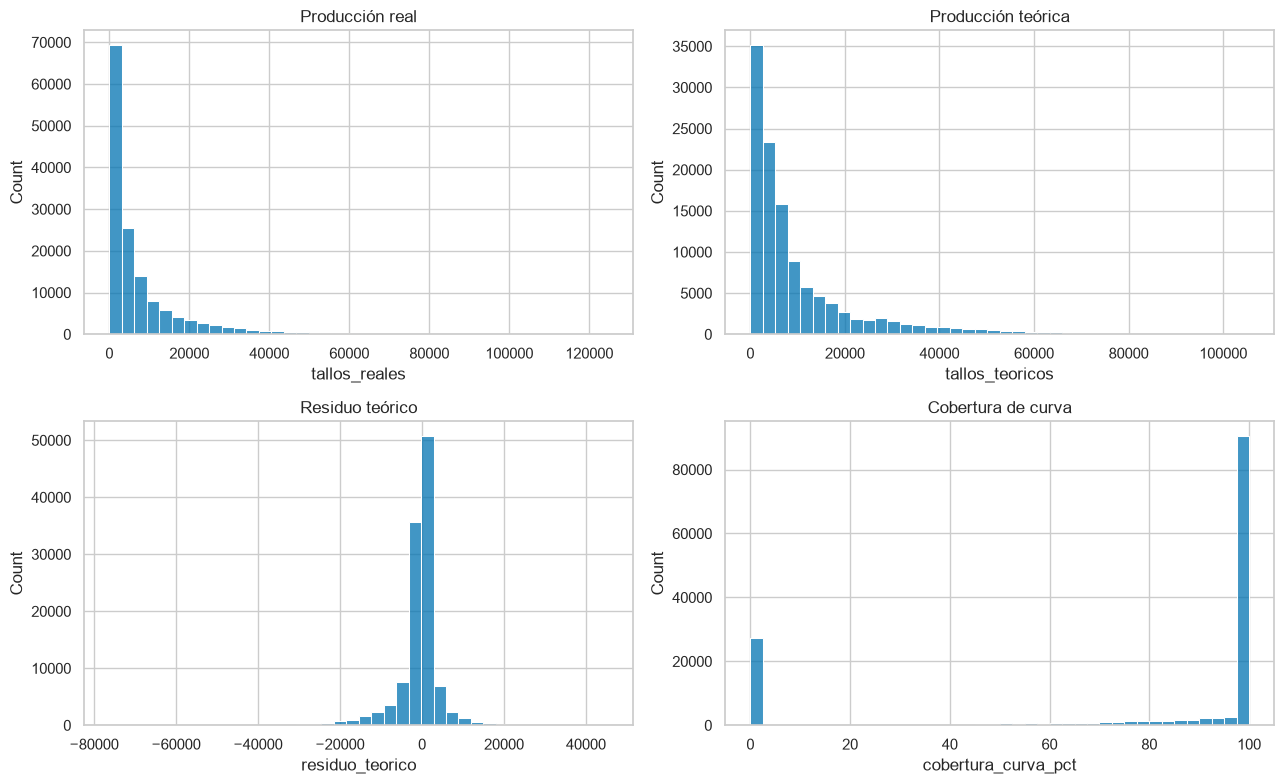

**Lectura de negocio.** Las distribuciones de tallos suelen ser asimétricas porque mezclan variedades y escalas productivas distintas. Esto favorece métricas robustas como WAPE y MAE; un error porcentual fila a fila puede ser inestable cuando el volumen planeado es pequeño.

In [8]:
variables_productivas = [
    "plantas", "edad_media_ponderada", "flores_planta_media_ponderada",
    "cobertura_curva_pct", "tallos_teoricos", "tallos_ingeniero", "tallos_reales",
    "residuo_teorico",
]
resumen_productivo = evaluables[variables_productivas].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
display(resumen_productivo)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col, titulo in zip(
    axes.flat,
    ["tallos_reales", "tallos_teoricos", "residuo_teorico", "cobertura_curva_pct"],
    ["Producción real", "Producción teórica", "Residuo teórico", "Cobertura de curva"],
):
    sns.histplot(evaluables[col].dropna(), bins=40, ax=ax)
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

display(Markdown(
    "**Lectura de negocio.** Las distribuciones de tallos suelen ser asimétricas porque mezclan "
    "variedades y escalas productivas distintas. Esto favorece métricas robustas como WAPE y MAE; "
    "un error porcentual fila a fila puede ser inestable cuando el volumen planeado es pequeño."
))


### 3.2. Tendencia semanal de producción y planeación

Para no contar varias veces la misma semana, esta visualización utiliza H1 y suma las variedades. Sirve para observar nivel, estacionalidad y cambios bruscos, no para decidir todavía una forma funcional del modelo.


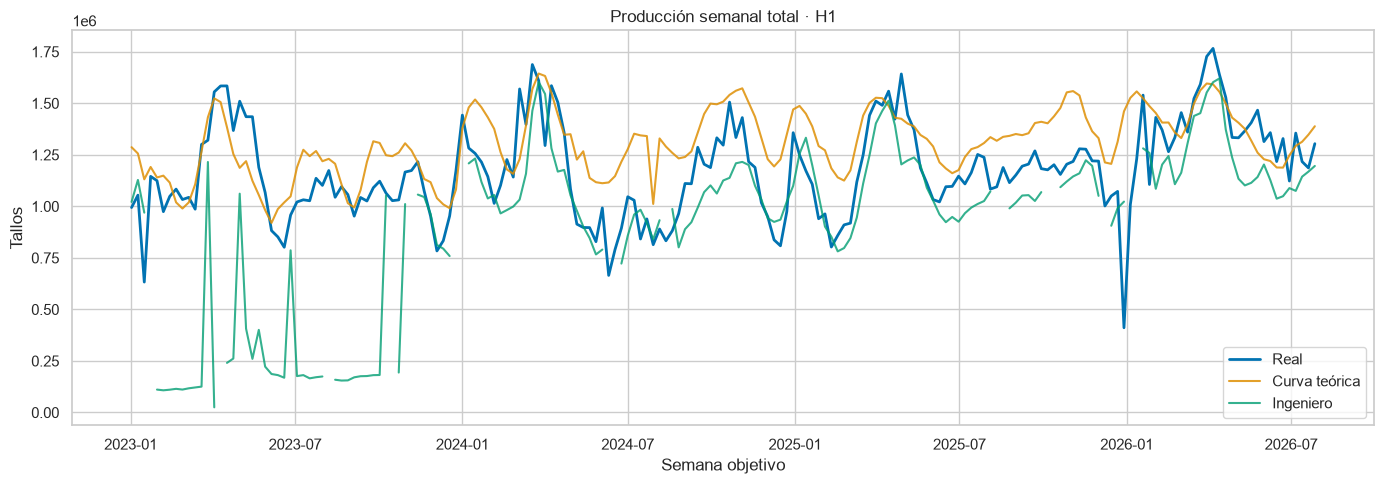

,lunes_objetivo,real,teorico,ingeniero,productos,variedades
177,2026-05-25,"1,466,371.000","1,260,260.035","1,142,410.000",11,178
178,2026-06-01,"1,314,139.000","1,228,503.463","1,202,970.000",11,132
179,2026-06-08,"1,357,500.000","1,219,789.257","1,127,540.000",11,145
180,2026-06-15,"1,217,267.000","1,188,551.363","1,037,190.000",11,133
181,2026-06-22,"1,328,767.000","1,187,818.078","1,049,130.000",11,139
182,2026-06-29,"1,122,857.000","1,247,377.286","1,088,530.000",11,133
183,2026-07-06,"1,355,298.000","1,293,316.795","1,074,960.000",11,134
184,2026-07-13,"1,216,976.000","1,313,300.844","1,144,020.000",11,142
185,2026-07-20,"1,186,292.000","1,347,807.013","1,168,490.000",11,133
186,2026-07-27,"1,303,995.000","1,388,531.048","1,195,900.000",11,134


In [9]:
serie_h1 = (
    evaluables[evaluables["horizonte"].eq(1)]
    .groupby("lunes_objetivo", as_index=False)
    .agg(
        real=("tallos_reales", "sum"),
        teorico=("tallos_teoricos", "sum"),
        ingeniero=("tallos_ingeniero", lambda x: x.sum(min_count=1)),
        productos=("k_producto", "nunique"),
        variedades=("k_variedad", "nunique"),
    )
    .sort_values("lunes_objetivo")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_h1["lunes_objetivo"], serie_h1["real"], label="Real", linewidth=2)
ax.plot(serie_h1["lunes_objetivo"], serie_h1["teorico"], label="Curva teórica", alpha=.85)
ax.plot(serie_h1["lunes_objetivo"], serie_h1["ingeniero"], label="Ingeniero", alpha=.8)
ax.set(title="Producción semanal total · H1", xlabel="Semana objetivo", ylabel="Tallos")
ax.legend()
plt.tight_layout()
plt.show()

display(serie_h1.tail(10))


### 3.3. Calidad de cobertura de la curva

Una desviación alta puede deberse a una mala curva, pero también a que parte del Plano no encontró una curva compatible. Por eso se revisa la cobertura antes de interpretar el residuo.


In [10]:
bandas_cobertura = pd.cut(
    evaluables["cobertura_curva_pct"],
    bins=[-np.inf, 50, 80, 95, 99, np.inf],
    labels=["≤50%", "50–80%", "80–95%", "95–99%", ">99%"],
)
calidad_cobertura = (
    evaluables.assign(banda_cobertura=bandas_cobertura)
    .groupby("banda_cobertura", observed=True)
    .agg(
        filas=("k_variedad", "size"),
        MAE_teorico=("error_absoluto_teorico", "mean"),
        residuo_medio=("residuo_teorico", "mean"),
        plantas=("plantas", "sum"),
    )
    .reset_index()
)
display(calidad_cobertura)

print("Interpretación: si el error empeora cuando la cobertura baja, primero debe mejorarse la unión Plano–Curva; no sería correcto atribuir todo el residuo al clima.")


,banda_cobertura,filas,MAE_teorico,residuo_medio,plantas
0,≤50%,31125,969.170,156.850,"93,200,241.000"
1,50–80%,9440,"1,681.867",-109.893,"385,190,473.000"
2,80–95%,10142,"2,371.484",-474.988,"539,087,055.000"
3,95–99%,5607,"3,784.189",133.183,"420,833,475.000"
4,>99%,87594,"3,139.085","-1,110.160","6,585,681,009.000"


Interpretación: si el error empeora cuando la cobertura baja, primero debe mejorarse la unión Plano–Curva; no sería correcto atribuir todo el residuo al clima.


## 4. Estimados frente a producción real

### 4.1. Comparación justa de benchmarks

Curva, ingeniero y persistencia deben evaluarse sobre las mismas filas. Las métricas ya fueron construidas con esa intersección común; se reporta cobertura para no ocultar cuántos casos quedaron fuera.


,horizonte,semanas_adelante,metodo,pares,cobertura_comun_pct,MAE_tallos,WAPE_pct,sesgo_tallos,sesgo_pct
0,1,0,curva,15499,38.331,"3,462.906",32.342,"1,286.259",12.013
1,1,0,ingeniero,15499,38.331,"2,217.390",20.709,-631.165,-5.895
2,1,0,persistencia,15499,38.331,"1,814.902",16.950,58.581,0.547
3,2,1,curva,15357,37.979,"3,382.133",31.664,"1,167.061",10.926
4,2,1,ingeniero,15357,37.979,"2,525.870",23.647,-588.498,-5.510
5,2,1,persistencia,15357,37.979,"2,561.469",23.981,106.474,0.997
6,3,2,curva,15202,37.596,"3,307.297",30.847,997.532,9.304
7,3,2,ingeniero,15202,37.596,"2,672.523",24.927,-654.778,-6.107
8,3,2,persistencia,15202,37.596,"3,206.102",29.903,94.194,0.879
9,4,3,curva,15065,37.257,"3,180.336",29.488,807.719,7.489


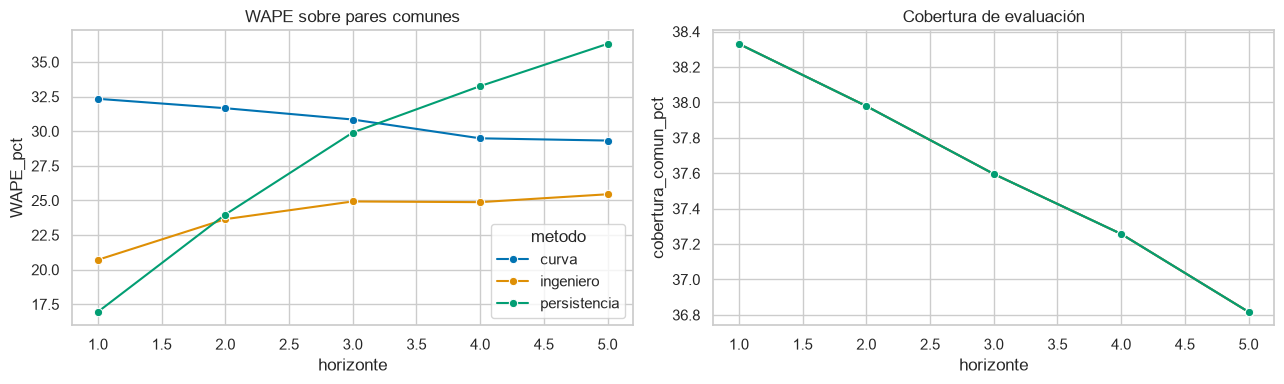

In [11]:
metricas_benchmarks = pd.read_csv(MODELADO / "metricas_benchmarks_comunes.csv")
display(metricas_benchmarks)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=metricas_benchmarks, x="horizonte", y="WAPE_pct", hue="metodo", marker="o", ax=axes[0])
sns.lineplot(data=metricas_benchmarks, x="horizonte", y="cobertura_comun_pct", hue="metodo", marker="o", ax=axes[1], legend=False)
axes[0].set_title("WAPE sobre pares comunes")
axes[1].set_title("Cobertura de evaluación")
plt.tight_layout()
plt.show()


### 4.2. Semanas con mayores desviaciones

Se agregan los residuos por semana objetivo en H1. El ranking se hace por error absoluto total para encontrar periodos operativamente importantes, no solamente porcentajes extremos sobre volúmenes pequeños.


,lunes_objetivo,real,teorico,ingeniero,residuo_teorico,error_absoluto_filas,cobertura_curva_media,error_absoluto_total,cumplimiento_teorico,error_pct_teorico
156,2025-12-29,"411,024.000","1,460,839.775","1,022,880.000","-1,051,702.775","1,051,772.775",69.097,"1,051,702.775",0.281,-71.993
157,2026-01-05,"1,008,710.000","1,526,300.924",NaN,"-521,820.924","614,226.542",67.781,"521,820.924",0.661,-34.189
80,2024-07-15,"841,658.000","1,344,220.450","983,540.000","-504,557.450","560,101.373",80.930,"504,557.450",0.626,-37.535
2,2023-01-16,"632,673.000","1,131,113.917","969,450.000","-498,651.917","587,202.971",94.956,"498,651.917",0.559,-44.085
84,2024-08-12,"832,934.000","1,289,891.003",NaN,"-459,278.003","546,657.989",86.600,"459,278.003",0.646,-35.606
75,2024-06-10,"665,019.000","1,115,828.658",NaN,"-452,200.658","516,827.177",77.309,"452,200.658",0.596,-40.526
83,2024-08-05,"890,027.000","1,329,439.383","932,720.000","-440,965.383","534,216.668",85.784,"440,965.383",0.669,-33.169
102,2024-12-16,"808,609.000","1,227,841.500","935,430.000","-420,966.500","489,218.516",84.855,"420,966.500",0.659,-34.285
81,2024-07-22,"938,869.000","1,340,912.035","919,560.000","-404,391.035","455,398.334",82.164,"404,391.035",0.700,-30.158
110,2025-02-10,"802,589.000","1,184,441.710","852,500.000","-386,297.710","427,860.043",75.611,"386,297.710",0.678,-32.614


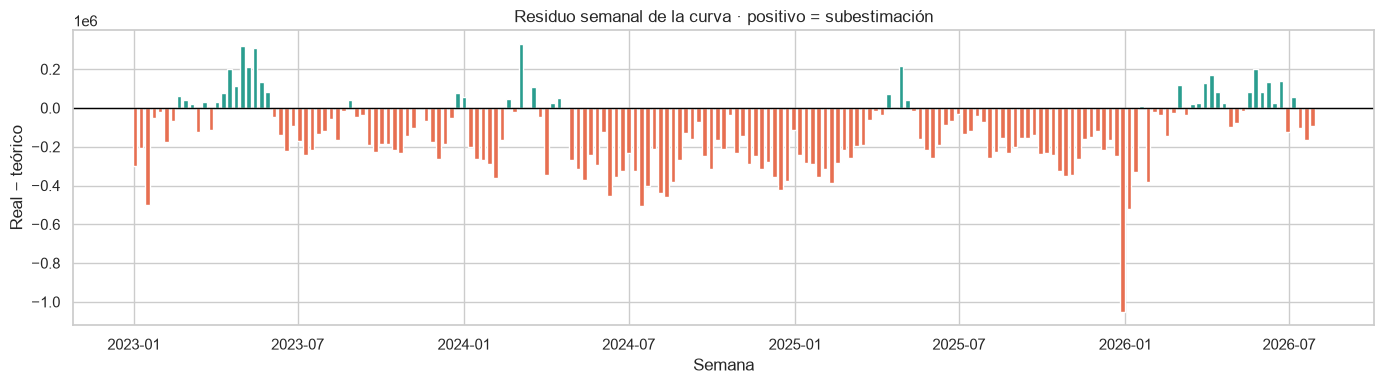

In [12]:
desviacion_semanal = (
    evaluables[evaluables["horizonte"].eq(1)]
    .groupby("lunes_objetivo", as_index=False)
    .agg(
        real=("tallos_reales", "sum"),
        teorico=("tallos_teoricos", "sum"),
        ingeniero=("tallos_ingeniero", lambda x: x.sum(min_count=1)),
        residuo_teorico=("residuo_teorico", "sum"),
        error_absoluto_filas=("error_absoluto_teorico", "sum"),
        cobertura_curva_media=("cobertura_curva_pct", "mean"),
    )
)
desviacion_semanal["error_absoluto_total"] = desviacion_semanal["residuo_teorico"].abs()
desviacion_semanal["cumplimiento_teorico"] = np.where(
    desviacion_semanal["teorico"].gt(0), desviacion_semanal["real"] / desviacion_semanal["teorico"], np.nan
)
desviacion_semanal["error_pct_teorico"] = np.where(
    desviacion_semanal["teorico"].gt(0), 100 * desviacion_semanal["residuo_teorico"] / desviacion_semanal["teorico"], np.nan
)

top_desviaciones = desviacion_semanal.nlargest(15, "error_absoluto_total")
display(top_desviaciones)

fig, ax = plt.subplots(figsize=(14, 4))
colores = np.where(desviacion_semanal["residuo_teorico"].ge(0), "#2A9D8F", "#E76F51")
ax.bar(desviacion_semanal["lunes_objetivo"], desviacion_semanal["residuo_teorico"], color=colores, width=5)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Residuo semanal de la curva · positivo = subestimación", xlabel="Semana", ylabel="Real − teórico")
plt.tight_layout()
plt.show()


### 4.3. Patrones por horizonte y producto

El horizonte puede cambiar el desempeño del ingeniero, mientras que la curva teórica depende principalmente del Plano y de las curvas disponibles. Las comparaciones por producto ayudan a detectar dónde un promedio general oculta problemas específicos.


In [13]:
def metricas_error(datos, real, predicho):
    pares = datos.dropna(subset=[real, predicho]).copy()
    error = pares[real] - pares[predicho]
    return pd.Series({
        "pares": len(pares),
        "MAE": error.abs().mean(),
        "WAPE_pct": 100 * error.abs().sum() / pares[real].sum() if pares[real].sum() else np.nan,
        "sesgo_tallos": error.mean(),
        "sesgo_pct": 100 * error.sum() / pares[real].sum() if pares[real].sum() else np.nan,
    })

metricas_producto = (
    evaluables.groupby("k_producto")
    .apply(metricas_error, real="tallos_reales", predicho="tallos_teoricos", include_groups=False)
    .reset_index()
    .sort_values("WAPE_pct", ascending=False)
)
display(metricas_producto)

print("Lectura: los productos con pocos pares o baja cobertura requieren cautela; un WAPE alto no demuestra por sí solo que la curva agronómica sea incorrecta.")


,k_producto,pares,MAE,WAPE_pct,sesgo_tallos,sesgo_pct
6,LEPIDIUM,256.000,"2,195.211",354.477,"-2,110.993",-340.878
0,ACHILLEA,942.000,56.183,79.768,21.087,29.939
13,TRACHELIUM,974.000,"1,035.186",51.062,621.135,30.638
15,VERONICA SPRAY,"1,790.000",823.793,43.741,-196.667,-10.442
2,BARBATUS,"5,219.000",584.170,41.666,-230.952,-16.473
14,VERONICA,"2,987.000",862.996,40.639,516.734,24.333
5,GREEN BALL,"2,039.000","3,012.493",37.906,"-1,672.543",-21.046
9,RAFFINE,"5,751.000","4,386.170",37.587,"3,665.076",31.408
12,STATICE,"1,939.000",297.908,37.359,159.654,20.021
1,AMAZON,925.000,925.128,35.674,220.075,8.486


Lectura: los productos con pocos pares o baja cobertura requieren cautela; un WAPE alto no demuestra por sí solo que la curva agronómica sea incorrecta.


## 5. Análisis climático

### 5.1. Disponibilidad temporal: seguro, condicionado y prohibido

- **Seguro:** semanas completamente anteriores a la emisión (`lag1` a `lag4`).
- **Condicionado:** semana de emisión; solo podría usarse si estaba completa al pronosticar.
- **Prohibido:** clima observado en la semana objetivo después de la emisión.

El EDA puede mirar información retrospectiva, pero la base del Notebook 3 excluirá las variables prohibidas.


In [14]:
columnas_clima_seguro = grupos_variables["clima seguro"]
columnas_clima_condicionado = grupos_variables["clima condicionado"]
columnas_clima_prohibido = grupos_variables["clima prohibido"]

separacion_clima = pd.DataFrame({
    "grupo": ["seguro", "condicionado", "prohibido"],
    "n_columnas": [len(columnas_clima_seguro), len(columnas_clima_condicionado), len(columnas_clima_prohibido)],
    "uso futuro": ["candidato principal", "pendiente por hora de emisión", "nunca predictor"],
})
display(separacion_clima)

display(pd.read_csv(AUDITORIA / "resumen_calidad_clima.csv"))
display(pd.read_csv(AUDITORIA / "clima_semanas_iso_invalidas.csv").head(20))
display(pd.read_csv(AUDITORIA / "clima_semanas_pocas_mediciones.csv").head(20))


,grupo,n_columnas,uso futuro
0,seguro,28,candidato principal
1,condicionado,7,pendiente por hora de emisión
2,prohibido,7,nunca predictor


,registros_fuente,registros_iso_invalidos,semanas_faltantes,umbral_pocas_mediciones,semanas_pocas_mediciones
0,294,3,0,336.000,25


,anio,semana,mediciones,temp_media,temp_min,temp_max,humedad_media,lluvia_acumulada,radiacion_media,et_acumulada,lunes,lunes_iso_validado,motivo
0,2021,53,848,13.951,5.400,23.100,81.163,48.720,179.085,50.800,NaN,NaN,Año-semana inválido ISO
1,2022,53,14,15.286,NaN,NaN,77.170,17.000,228.857,56.520,NaN,NaN,Año-semana inválido ISO
2,2024,53,110,13.842,9.200,20.700,92.227,3.810,114.600,4.190,NaN,NaN,Año-semana inválido ISO


,anio,semana,mediciones,temp_media,temp_min,temp_max,humedad_media,lluvia_acumulada,radiacion_media,et_acumulada,lunes,lunes_iso_validado,umbral_percentil_10
0,2021,10,124,14.585,11.300,19.400,81.895,179.200,181.814,81.560,2021-03-08,2021-03-08,336.000
1,2021,11,30,15.133,15.000,15.100,76.645,149.200,307.819,93.980,2021-03-15,2021-03-15,336.000
2,2021,12,30,15.000,15.000,15.100,77.101,206.000,293.136,87.220,2021-03-22,2021-03-22,336.000
3,2021,34,122,13.526,9.500,21.700,82.087,45.900,225.673,89.460,2021-08-23,2021-08-23,336.000
4,2023,1,28,14.714,NaN,NaN,77.755,28.800,158.571,82.840,2023-01-02,2023-01-02,336.000
5,2023,2,28,14.429,NaN,NaN,76.913,99.600,179.429,88.920,2023-01-09,2023-01-09,336.000
6,2023,3,310,13.384,8.400,20.700,78.840,73.520,203.626,87.920,2023-01-16,2023-01-16,336.000
7,2025,52,332,14.092,3.000,23.300,83.488,1.500,225.336,23.870,2025-12-22,2025-12-22,336.000
8,2026,1,192,13.566,7.000,20.800,84.891,1.520,134.995,8.560,2025-12-29,2025-12-29,336.000
9,2026,4,334,14.111,4.500,23.100,86.443,30.440,191.810,20.110,2026-01-19,2026-01-19,336.000


### 5.2. Construir una tabla climática semanal sin ponderar por productos

El mismo clima se repite en muchas filas de producto-color-variedad. Para estudiar su distribución se conserva una sola fila por semana de emisión; de lo contrario, las semanas con más variedades pesarían artificialmente más.


In [15]:
clima_semanal = (
    df_eda[["lunes_emision", *columnas_clima_seguro]]
    .sort_values("lunes_emision")
    .drop_duplicates("lunes_emision")
    .reset_index(drop=True)
)
print("Semanas climáticas únicas:", len(clima_semanal))
display(clima_semanal.head())
display(clima_semanal[columnas_clima_seguro].describe().T)


Semanas climáticas únicas: 189


,lunes_emision,temp_media_lag1_seguro,temp_min_lag1_seguro,temp_max_lag1_seguro,humedad_media_lag1_seguro,lluvia_acumulada_lag1_seguro,radiacion_media_lag1_seguro,et_acumulada_lag1_seguro,temp_media_lag2_seguro,temp_min_lag2_seguro,temp_max_lag2_seguro,humedad_media_lag2_seguro,lluvia_acumulada_lag2_seguro,radiacion_media_lag2_seguro,et_acumulada_lag2_seguro,temp_media_lag3_seguro,temp_min_lag3_seguro,temp_max_lag3_seguro,humedad_media_lag3_seguro,lluvia_acumulada_lag3_seguro,radiacion_media_lag3_seguro,et_acumulada_lag3_seguro,temp_media_lag4_seguro,temp_min_lag4_seguro,temp_max_lag4_seguro,humedad_media_lag4_seguro,lluvia_acumulada_lag4_seguro,radiacion_media_lag4_seguro,et_acumulada_lag4_seguro
0,2023-01-02,13.059,3.800,22.900,82.351,84.060,219.080,115.790,12.404,2.800,22.600,82.876,43.420,199.524,98.640,12.539,2.800,22.600,84.094,127.760,174.876,91.280,12.817,4.800,20.400,86.255,139.050,157.614,78.280
1,2023-01-09,14.714,NaN,NaN,77.755,28.800,158.571,82.840,13.059,3.800,22.900,82.351,84.060,219.080,115.790,12.404,2.800,22.600,82.876,43.420,199.524,98.640,12.539,2.800,22.600,84.094,127.760,174.876,91.280
2,2023-01-16,14.429,NaN,NaN,76.913,99.600,179.429,88.920,14.714,NaN,NaN,77.755,28.800,158.571,82.840,13.059,3.800,22.900,82.351,84.060,219.080,115.790,12.404,2.800,22.600,82.876,43.420,199.524,98.640
3,2023-01-23,13.384,8.400,20.700,78.840,73.520,203.626,87.920,14.429,NaN,NaN,76.913,99.600,179.429,88.920,14.714,NaN,NaN,77.755,28.800,158.571,82.840,13.059,3.800,22.900,82.351,84.060,219.080,115.790
4,2023-01-30,12.078,1.300,23.100,78.331,0.000,210.384,90.900,13.384,8.400,20.700,78.840,73.520,203.626,87.920,14.429,NaN,NaN,76.913,99.600,179.429,88.920,14.714,NaN,NaN,77.755,28.800,158.571,82.840


,count,mean,std,min,25%,50%,75%,max
temp_media_lag1_seguro,188.000,14.426,0.890,11.983,13.920,14.278,14.824,17.108
temp_min_lag1_seguro,186.000,6.728,2.371,0.300,5.200,6.700,8.300,11.900
temp_max_lag1_seguro,186.000,22.907,1.595,19.600,21.800,22.800,23.600,28.600
humedad_media_lag1_seguro,188.000,83.371,4.954,55.650,81.014,84.097,86.567,92.952
lluvia_acumulada_lag1_seguro,188.000,34.858,36.004,0.000,6.245,25.985,52.240,186.480
radiacion_media_lag1_seguro,188.000,169.999,23.812,113.187,152.986,167.654,185.981,245.484
et_acumulada_lag1_seguro,175.000,53.501,22.386,3.730,36.260,53.180,70.150,115.790
temp_media_lag2_seguro,189.000,14.415,0.899,11.983,13.897,14.276,14.821,17.108
temp_min_lag2_seguro,187.000,6.707,2.382,0.300,5.150,6.700,8.300,11.900
temp_max_lag2_seguro,187.000,22.905,1.590,19.600,21.800,22.800,23.600,28.600


### 5.3. Distribuciones, tendencias y reducción de ruido

Para una lectura sencilla se muestran las variables de `lag1`, que corresponden a la semana completamente anterior. La media móvil de cuatro semanas reduce ruido visual; no reemplaza la medición original.


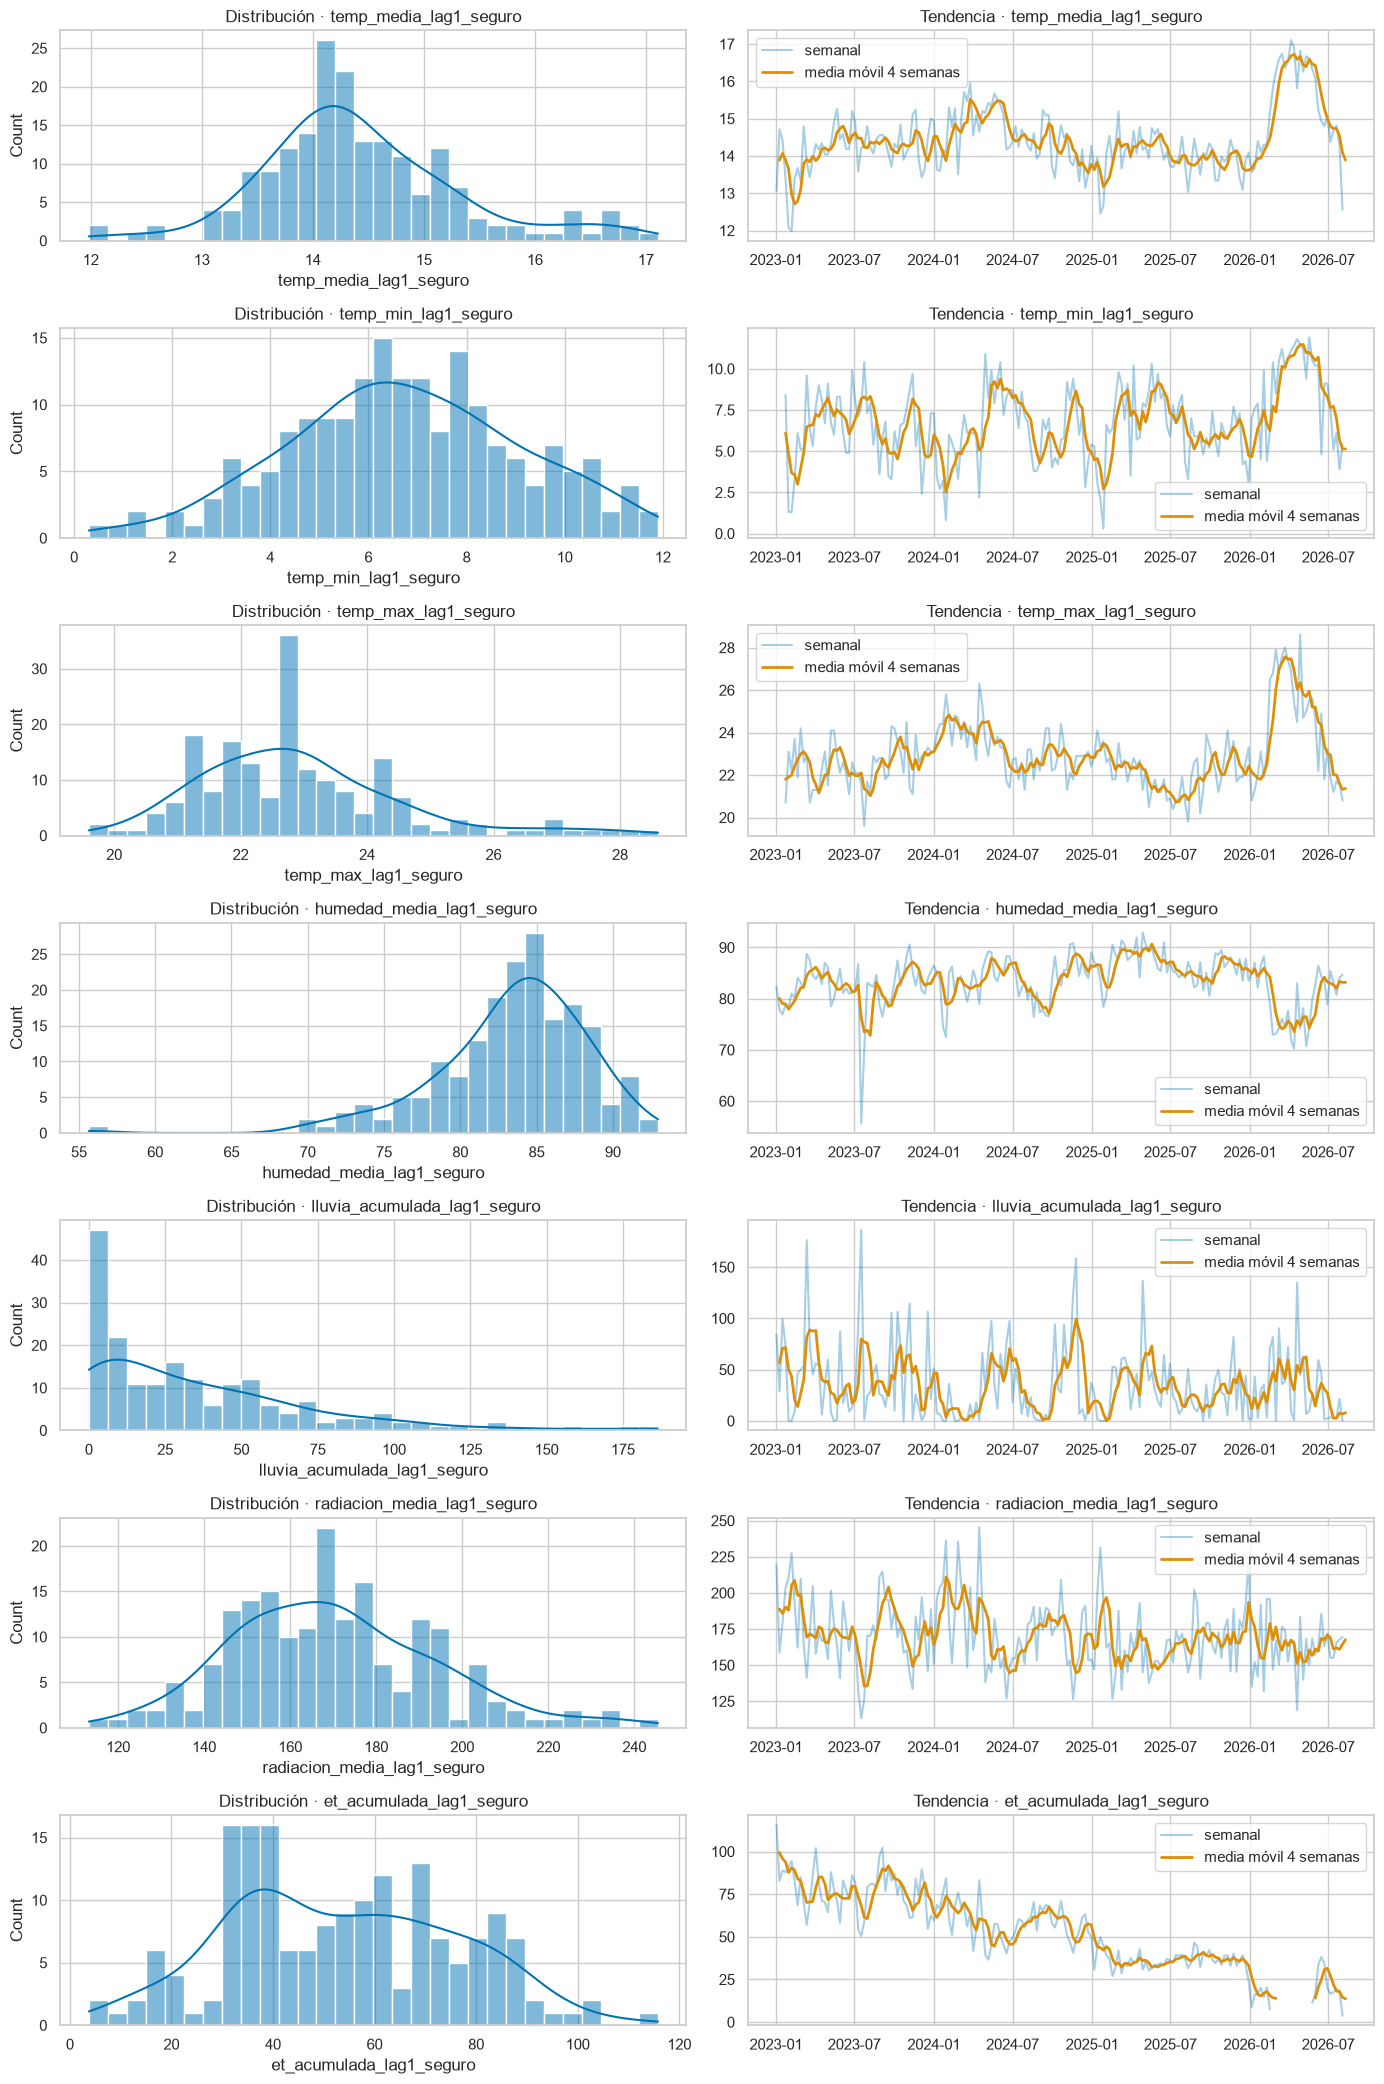

In [16]:
clima_lag1 = [c for c in columnas_clima_seguro if "_lag1_seguro" in c]
etiquetas_clima = {
    "temp_media_lag1_seguro": "Temperatura media",
    "humedad_media_lag1_seguro": "Humedad media",
    "lluvia_acumulada_lag1_seguro": "Lluvia acumulada",
    "radiacion_media_lag1_seguro": "Radiación media",
    "et_acumulada_lag1_seguro": "ET acumulada",
}

fig, axes = plt.subplots(len(clima_lag1), 2, figsize=(14, 3 * len(clima_lag1)))
for i, col in enumerate(clima_lag1):
    sns.histplot(clima_semanal[col].dropna(), bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución · {col}")
    axes[i, 1].plot(clima_semanal["lunes_emision"], clima_semanal[col], alpha=.35, label="semanal")
    axes[i, 1].plot(
        clima_semanal["lunes_emision"], clima_semanal[col].rolling(4, min_periods=2).mean(),
        linewidth=2, label="media móvil 4 semanas",
    )
    axes[i, 1].set_title(f"Tendencia · {col}")
    axes[i, 1].legend()
plt.tight_layout()
plt.show()


### 5.4. Detección exploratoria de valores extremos

Se usa la regla del rango intercuartílico (1,5 × IQR) como señal de revisión, no como orden de eliminación. Un extremo simultáneo en variables relacionadas y consistente durante varios días puede ser un evento real; un salto aislado, físicamente improbable o sin respaldo en otras mediciones puede ser un error de sensor. La decisión definitiva requiere la base diaria y validación operativa.


In [17]:
def detectar_outliers_iqr(datos, columnas):
    resumen, banderas = [], pd.DataFrame(index=datos.index)
    for col in columnas:
        q1, q3 = datos[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        bandera = datos[col].lt(inferior) | datos[col].gt(superior)
        banderas[f"outlier_{col}"] = bandera.fillna(False)
        resumen.append({
            "variable": col, "Q1": q1, "Q3": q3, "límite_inferior": inferior,
            "límite_superior": superior, "semanas_extremas": int(bandera.sum()),
        })
    return pd.DataFrame(resumen), banderas

resumen_outliers, banderas_outliers = detectar_outliers_iqr(clima_semanal, clima_lag1)
clima_eventos = pd.concat([clima_semanal, banderas_outliers], axis=1)
clima_eventos["n_variables_extremas"] = banderas_outliers.sum(axis=1)

display(resumen_outliers)
display(clima_eventos.nlargest(20, "n_variables_extremas")[[
    "lunes_emision", "n_variables_extremas", *clima_lag1,
]])


,variable,Q1,Q3,límite_inferior,límite_superior,semanas_extremas
0,temp_media_lag1_seguro,13.920,14.824,12.564,16.180,16
1,temp_min_lag1_seguro,5.200,8.300,0.550,12.950,1
2,temp_max_lag1_seguro,21.800,23.600,19.100,26.300,9
3,humedad_media_lag1_seguro,81.014,86.567,72.683,94.898,6
4,lluvia_acumulada_lag1_seguro,6.245,52.240,-62.748,121.233,6
5,radiacion_media_lag1_seguro,152.986,185.981,103.495,235.473,2
6,et_acumulada_lag1_seguro,36.260,70.150,-14.575,120.985,0


,lunes_emision,n_variables_extremas,temp_media_lag1_seguro,temp_min_lag1_seguro,temp_max_lag1_seguro,humedad_media_lag1_seguro,lluvia_acumulada_lag1_seguro,radiacion_media_lag1_seguro,et_acumulada_lag1_seguro
170,2026-04-06,3,17.108,11.100,26.900,71.931,9.100,166.779,NaN
28,2023-07-17,2,14.214,7.700,21.600,55.650,186.480,113.187,50.460
56,2024-01-29,2,14.078,0.800,25.800,72.494,0.000,236.514,84.290
165,2026-03-02,2,16.263,8.500,27.900,73.170,0.000,167.153,NaN
166,2026-03-09,2,16.598,10.500,26.800,74.224,90.300,150.465,NaN
167,2026-03-16,2,16.741,11.200,27.600,76.107,35.900,176.531,NaN
168,2026-03-23,2,16.355,10.100,28.000,74.373,38.300,174.091,NaN
169,2026-03-30,2,16.537,10.700,27.400,77.712,72.300,152.479,NaN
171,2026-04-13,2,16.899,11.400,25.400,70.237,0.700,166.282,NaN
173,2026-04-27,2,16.820,11.500,28.600,74.191,44.900,183.223,NaN


## 6. PCA climático

El PCA se aplica únicamente al clima **seguro**. Se trabaja con una fila por semana, se imputan faltantes con la mediana y se estandariza porque temperatura, lluvia, humedad y radiación usan escalas diferentes.

Esta aplicación es exploratoria. En el Notebook 3, imputación, escalado y PCA deberán ajustarse solamente con cada conjunto de entrenamiento para evitar fuga temporal.


,componente,varianza_pct,varianza_acumulada_pct
0,PC1,24.861,24.861
1,PC2,19.206,44.067
2,PC3,9.565,53.632
3,PC4,7.347,60.979
4,PC5,5.023,66.002
5,PC6,4.566,70.569
6,PC7,3.849,74.418
7,PC8,3.691,78.109
8,PC9,2.863,80.972
9,PC10,2.522,83.493


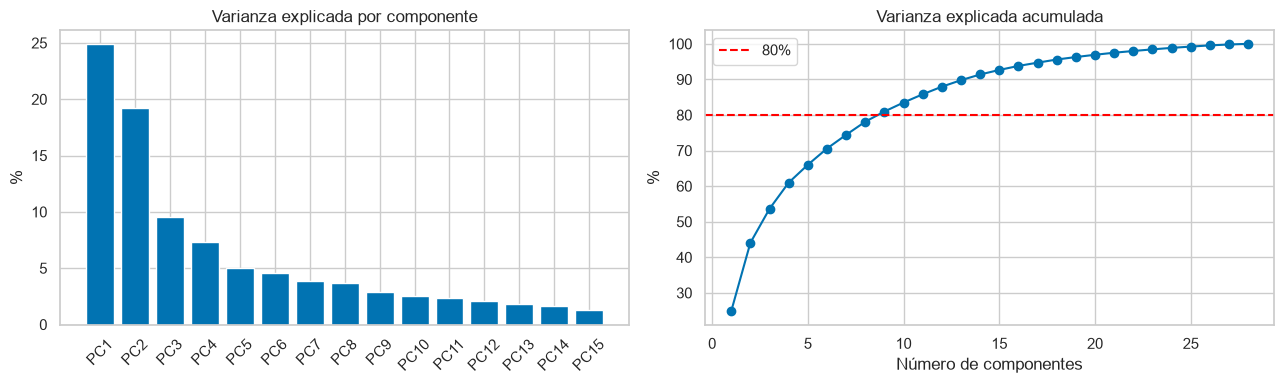

In [18]:
X_clima = clima_semanal[columnas_clima_seguro].copy()
imputador_pca = SimpleImputer(strategy="median")
escalador_pca = StandardScaler()

# 1) Los faltantes se imputan con la mediana de cada variable.
X_imputado = imputador_pca.fit_transform(X_clima)
# 2) Todas las variables quedan en una escala comparable.
X_estandarizado = escalador_pca.fit_transform(X_imputado)
# 3) Se ajusta el PCA exploratorio.
pca = PCA()
componentes = pca.fit_transform(X_estandarizado)
razon_varianza = pca.explained_variance_ratio_

varianza_pca = pd.DataFrame({
    "componente": [f"PC{i}" for i in range(1, len(razon_varianza) + 1)],
    "varianza_pct": 100 * razon_varianza,
    "varianza_acumulada_pct": 100 * np.cumsum(razon_varianza),
})
display(varianza_pca.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(varianza_pca["componente"].head(15), varianza_pca["varianza_pct"].head(15))
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(title="Varianza explicada por componente", ylabel="%")
axes[1].plot(range(1, len(varianza_pca) + 1), varianza_pca["varianza_acumulada_pct"], marker="o")
axes[1].axhline(80, color="red", linestyle="--", label="80%")
axes[1].set(title="Varianza explicada acumulada", xlabel="Número de componentes", ylabel="%")
axes[1].legend()
plt.tight_layout()
plt.show()


### 6.1. Interpretar los componentes

Las cargas indican qué variables se mueven juntas dentro de cada componente. El signo es relativo: lo importante es la magnitud y la oposición entre grupos de variables. La interpretación agrícola debe apoyarse en temperatura, humedad, balance hídrico y energía disponible, no solamente en el número matemático del componente.


Componentes necesarios para explicar al menos 80%: 9


,componente,variable,carga,carga_absoluta
0,PC1,temp_media_lag2_seguro,0.329,0.329
1,PC1,temp_media_lag3_seguro,0.324,0.324
2,PC1,temp_media_lag1_seguro,0.310,0.310
3,PC1,temp_media_lag4_seguro,0.298,0.298
4,PC1,temp_max_lag4_seguro,0.278,0.278
5,PC1,temp_max_lag3_seguro,0.269,0.269
6,PC2,et_acumulada_lag3_seguro,0.345,0.345
7,PC2,et_acumulada_lag2_seguro,0.343,0.343
8,PC2,et_acumulada_lag4_seguro,0.323,0.323
9,PC2,et_acumulada_lag1_seguro,0.316,0.316


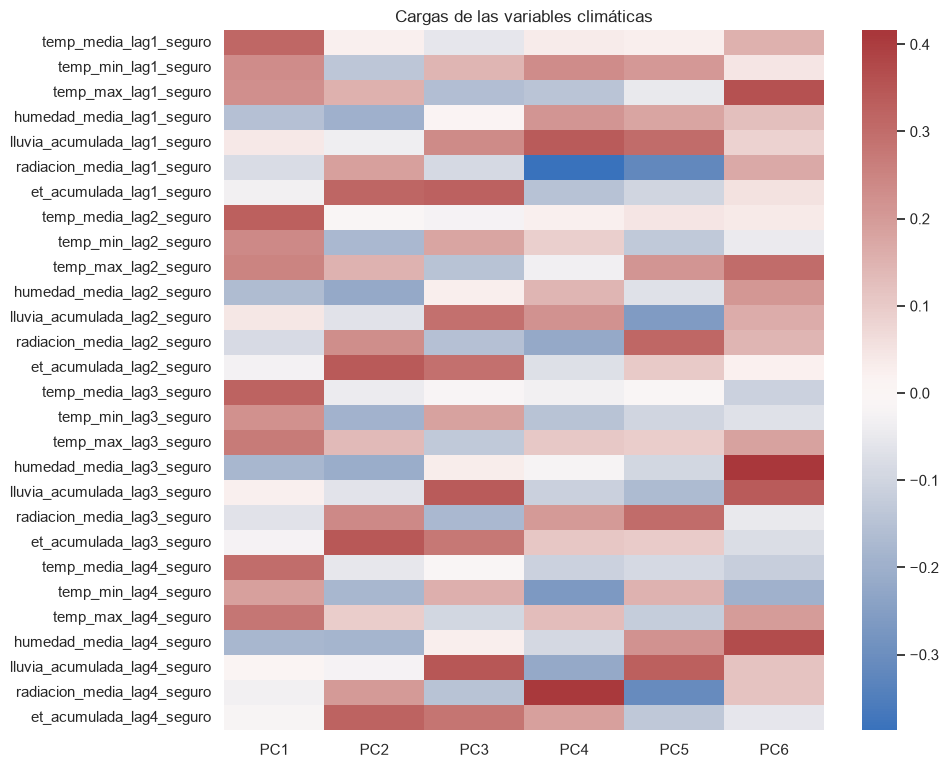

Interpretación prudente: componentes dominados por radiación/ET representan disponibilidad energética; componentes con humedad y lluvia representan condiciones hídricas; temperatura mínima y máxima pueden capturar nivel térmico y amplitud. Los nombres definitivos deben asignarse mirando las cargas observadas.


In [19]:
n_componentes_80 = int(np.argmax(varianza_pca["varianza_acumulada_pct"].to_numpy() >= 80) + 1)
n_mostrar = min(max(n_componentes_80, 3), 6)

cargas_pca = pd.DataFrame(
    pca.components_[:n_mostrar].T,
    index=columnas_clima_seguro,
    columns=[f"PC{i}" for i in range(1, n_mostrar + 1)],
)

aportes_principales = []
for componente in cargas_pca.columns:
    principales = cargas_pca[componente].abs().nlargest(6).index
    for variable in principales:
        aportes_principales.append({
            "componente": componente,
            "variable": variable,
            "carga": cargas_pca.loc[variable, componente],
            "carga_absoluta": abs(cargas_pca.loc[variable, componente]),
        })

print(f"Componentes necesarios para explicar al menos 80%: {n_componentes_80}")
display(pd.DataFrame(aportes_principales))

fig, ax = plt.subplots(figsize=(10, max(7, len(cargas_pca) * .28)))
sns.heatmap(cargas_pca, cmap="vlag", center=0, ax=ax)
ax.set_title("Cargas de las variables climáticas")
plt.tight_layout()
plt.show()

print("Interpretación prudente: componentes dominados por radiación/ET representan disponibilidad energética; componentes con humedad y lluvia representan condiciones hídricas; temperatura mínima y máxima pueden capturar nivel térmico y amplitud. Los nombres definitivos deben asignarse mirando las cargas observadas.")


## 7. Relaciones entre clima, producción y desviaciones

### 7.1. Crear una tabla semanal comparable

Se usa H1, una semana objetivo por fecha y clima de `lag1`. Los volúmenes se suman; el cumplimiento se calcula después de agregar, evitando promediar porcentajes de variedades pequeñas y grandes por igual.


,tallos_reales,residuo_teorico,cumplimiento_teorico
temp_media,0.278,0.357,0.348
temp_min,0.223,0.272,0.255
temp_max,0.186,0.097,0.119
humedad_media,-0.018,-0.179,-0.165
lluvia_acumulada,-0.005,0.011,0.007
radiacion_media,-0.027,0.006,0.020
et_acumulada,-0.197,0.124,0.098


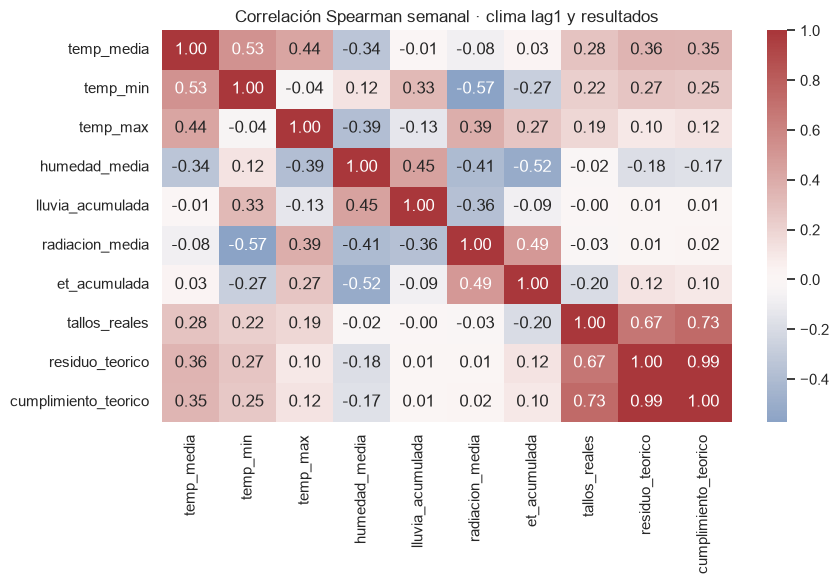

In [20]:
clima_lag1_renombrado = {c: c.replace("_lag1_seguro", "") for c in clima_lag1}

semana_clima_produccion = (
    evaluables[evaluables["horizonte"].eq(1)]
    .groupby("lunes_objetivo", as_index=False)
    .agg(
        tallos_reales=("tallos_reales", "sum"),
        tallos_teoricos=("tallos_teoricos", "sum"),
        residuo_teorico=("residuo_teorico", "sum"),
        **{clima_lag1_renombrado[c]: (c, "first") for c in clima_lag1},
    )
    .sort_values("lunes_objetivo")
)
semana_clima_produccion["cumplimiento_teorico"] = np.where(
    semana_clima_produccion["tallos_teoricos"].gt(0),
    semana_clima_produccion["tallos_reales"] / semana_clima_produccion["tallos_teoricos"],
    np.nan,
)

variables_clima_corr = list(clima_lag1_renombrado.values())
variables_resultado = ["tallos_reales", "residuo_teorico", "cumplimiento_teorico"]
correlacion_spearman = semana_clima_produccion[
    variables_clima_corr + variables_resultado
].corr(method="spearman")

display(correlacion_spearman.loc[variables_clima_corr, variables_resultado])

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(correlacion_spearman, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlación Spearman semanal · clima lag1 y resultados")
plt.tight_layout()
plt.show()


### 7.2. Coincidencia entre eventos climáticos y desviaciones

Se unen las banderas climáticas por semana de emisión con la desviación de su semana objetivo H1. La tabla identifica semanas para investigar, pero no permite afirmar que el clima causó el error: también pueden intervenir labores, sanidad, cambios de área, calidad de curvas o registros faltantes.


In [21]:
eventos_h1 = desviacion_semanal.merge(
    clima_eventos.rename(columns={"lunes_emision": "lunes_objetivo"}),
    on="lunes_objetivo", how="left", validate="one_to_one",
)
eventos_h1["desviacion_grande"] = eventos_h1["error_absoluto_total"].ge(
    eventos_h1["error_absoluto_total"].quantile(.90)
)

eventos_importantes = eventos_h1[
    eventos_h1["desviacion_grande"] | eventos_h1["n_variables_extremas"].gt(0)
].sort_values(["desviacion_grande", "n_variables_extremas", "error_absoluto_total"], ascending=False)

columnas_eventos = [
    "lunes_objetivo", "real", "teorico", "residuo_teorico", "error_pct_teorico",
    "cobertura_curva_media", "n_variables_extremas", "desviacion_grande", *clima_lag1,
]
display(eventos_importantes[columnas_eventos].head(30))

coincidencias = eventos_h1.groupby("desviacion_grande")["n_variables_extremas"].agg(["count", "mean", "max"])
display(coincidencias)
print("Lectura: una mayor frecuencia de extremos en semanas desviadas sería una señal exploratoria. Aun así, se necesita controlar estacionalidad, producto, edad, labores y calidad de medición.")


,lunes_objetivo,real,teorico,residuo_teorico,error_pct_teorico,cobertura_curva_media,n_variables_extremas,desviacion_grande,temp_media_lag1_seguro,temp_min_lag1_seguro,temp_max_lag1_seguro,humedad_media_lag1_seguro,lluvia_acumulada_lag1_seguro,radiacion_media_lag1_seguro,et_acumulada_lag1_seguro
108,2025-01-27,"939,929.000","1,292,469.766","-357,634.766",-27.671,76.731,1,True,12.660,0.300,23.600,78.411,0.000,193.815,44.880
156,2025-12-29,"411,024.000","1,460,839.775","-1,051,702.775",-71.993,69.097,0,True,14.092,3.000,23.300,83.488,1.500,225.336,23.870
157,2026-01-05,"1,008,710.000","1,526,300.924","-521,820.924",-34.189,67.781,0,True,13.566,7.000,20.800,84.891,1.520,134.995,8.560
80,2024-07-15,"841,658.000","1,344,220.450","-504,557.450",-37.535,80.930,0,True,14.248,6.400,21.800,80.379,35.040,169.082,60.350
2,2023-01-16,"632,673.000","1,131,113.917","-498,651.917",-44.085,94.956,0,True,14.429,NaN,NaN,76.913,99.600,179.429,88.920
84,2024-08-12,"832,934.000","1,289,891.003","-459,278.003",-35.606,86.600,0,True,14.140,5.200,23.200,82.372,23.050,180.545,61.410
75,2024-06-10,"665,019.000","1,115,828.658","-452,200.658",-40.526,77.309,0,True,15.087,7.200,23.300,84.699,42.150,154.965,45.370
83,2024-08-05,"890,027.000","1,329,439.383","-440,965.383",-33.169,85.784,0,True,14.276,6.800,23.200,79.768,4.310,178.119,59.730
102,2024-12-16,"808,609.000","1,227,841.500","-420,966.500",-34.285,84.855,0,True,13.148,2.800,22.900,85.080,0.750,191.085,63.210
81,2024-07-22,"938,869.000","1,340,912.035","-404,391.035",-30.158,82.164,0,True,14.710,8.600,22.600,82.016,6.780,162.524,59.460


,count,mean,max
desviacion_grande,,,
False,168,0.226,3
True,19,0.053,1


Lectura: una mayor frecuencia de extremos en semanas desviadas sería una señal exploratoria. Aun así, se necesita controlar estacionalidad, producto, edad, labores y calidad de medición.


## 8. Preparación para modelamiento

### 8.1. Clasificar variables por su uso permitido

El objetivo recomendado para un primer experimento es `residuo_teorico`. Así el modelo futuro aprendería una corrección sobre la producción de curvas:

`pronostico_corregido = tallos_teoricos + residuo_predicho`

La producción real y los residuos observados son etiquetas, no predictores. El clima objetivo observado está prohibido. El estimado del ingeniero puede utilizarse como benchmark o como predictor en un experimento separado si el propósito es complementarlo.


In [22]:
identificadores = [
    "anio_emision", "semana_emision", "lunes_emision", "anio_objetivo",
    "semana_objetivo", "lunes_objetivo", "horizonte", "semanas_adelante",
    "k_producto", "k_color", "k_variedad", "estado_objetivo",
]
predictoras_productivas = [
    "plantas", "segmentos_plan", "camas_plan_unicas", "edad_media_ponderada",
    "edad_min", "edad_max", "edad_desviacion", "plantas_edad_0_25",
    "plantas_edad_26_50", "plantas_edad_51_75", "plantas_edad_76_mas",
    "tallos_teoricos", "flores_planta_media_ponderada", "curva_iqr_media_ponderada",
    "cobertura_curva_pct", "observaciones_curva", "camas_curva",
]
predictoras_seguras = predictoras_productivas + columnas_clima_seguro
predictoras_condicionadas = columnas_clima_condicionado + ["tallos_ingeniero"]
objetivos_y_evaluacion = [
    "tallos_reales", "residuo_teorico", "residuo_ingeniero", "residuo_persistencia",
]
prohibidas = columnas_clima_prohibido

clasificacion_modelo = pd.DataFrame([
    ["identificador", len(identificadores), "separa tiempo y categorías; no todos se codifican igual"],
    ["predictor seguro", len(predictoras_seguras), "disponible antes de la semana objetivo"],
    ["predictor condicionado", len(predictoras_condicionadas), "requiere confirmar hora y propósito de emisión"],
    ["objetivo/evaluación", len(objetivos_y_evaluacion), "nunca entra como predictor"],
    ["prohibido", len(prohibidas), "información posterior a la emisión"],
], columns=["rol", "n_variables", "decisión"])
display(clasificacion_modelo)


,rol,n_variables,decisión
0,identificador,12,separa tiempo y categorías; no todos se codifi...
1,predictor seguro,45,disponible antes de la semana objetivo
2,predictor condicionado,8,requiere confirmar hora y propósito de emisión
3,objetivo/evaluación,4,nunca entra como predictor
4,prohibido,7,información posterior a la emisión


### 8.2. Materializar la base para el Notebook 3

La base conserva todos los estados para trazabilidad, pero incluye `es_entrenable`: solamente `real_observado` puede participar como etiqueta. No se imputan variables productivas aquí. La imputación y el escalamiento deberán ajustarse dentro de cada corte temporal de entrenamiento.


In [23]:
columnas_salida = list(dict.fromkeys(
    identificadores + predictoras_seguras + predictoras_condicionadas
    + objetivos_y_evaluacion + prohibidas
))
columnas_salida = [c for c in columnas_salida if c in df_eda.columns]

df_modelo_notebook3 = df_eda[columnas_salida].copy()
df_modelo_notebook3["es_entrenable"] = df_modelo_notebook3["estado_objetivo"].eq("real_observado")

ruta_salida_modelo3 = MODELADO / "df_modelo_notebook3.parquet"
df_modelo_notebook3.to_parquet(ruta_salida_modelo3, index=False)

diccionario_modelo3 = []
for columna in df_modelo_notebook3.columns:
    if columna in predictoras_seguras:
        rol = "predictor_seguro"
    elif columna in predictoras_condicionadas:
        rol = "predictor_condicionado"
    elif columna in prohibidas:
        rol = "prohibido_como_predictor"
    elif columna in objetivos_y_evaluacion:
        rol = "objetivo_o_evaluacion"
    else:
        rol = "identificador_control"
    diccionario_modelo3.append({
        "variable": columna,
        "tipo": str(df_modelo_notebook3[columna].dtype),
        "rol": rol,
        "nulos": int(df_modelo_notebook3[columna].isna().sum()),
        "nulos_pct": 100 * df_modelo_notebook3[columna].isna().mean(),
    })

diccionario_modelo3 = pd.DataFrame(diccionario_modelo3)
diccionario_modelo3.to_csv(MODELADO / "diccionario_variables_notebook3.csv", index=False)

print("Base guardada:", ruta_salida_modelo3.relative_to(RAIZ))
print("Dimensiones:", df_modelo_notebook3.shape)
display(diccionario_modelo3)


Base guardada: Datos\modelado\df_modelo_notebook3.parquet
Dimensiones: (202175, 77)


,variable,tipo,rol,nulos,nulos_pct
0,anio_emision,int64,identificador_control,0,0.000
1,semana_emision,int64,identificador_control,0,0.000
2,lunes_emision,datetime64[us],identificador_control,0,0.000
3,anio_objetivo,int64,identificador_control,0,0.000
4,semana_objetivo,int64,identificador_control,0,0.000
...,...,...,...,...,...
72,humedad_media_objetivo_prohibido,float64,prohibido_como_predictor,4298,2.126
73,lluvia_acumulada_objetivo_prohibido,float64,prohibido_como_predictor,4298,2.126
74,radiacion_media_objetivo_prohibido,float64,prohibido_como_predictor,4298,2.126
75,et_acumulada_objetivo_prohibido,float64,prohibido_como_predictor,20375,10.078


### 8.3. Validación temporal propuesta

No se utilizará división aleatoria. Los cortes se realizan por semana objetivo completa:

1. entrenar con 2023 y validar en 2024;
2. entrenar con 2023–2024 y validar en 2025;
3. entrenar con 2023–2025 y reservar 2026 como prueba final.

Una misma semana objetivo no puede estar simultáneamente en entrenamiento y validación por aparecer en horizontes diferentes.


In [24]:
cortes_temporales = pd.read_csv(MODELADO / "cortes_validacion_temporal.csv")
display(cortes_temporales)

validacion_cortes = []
for _, corte in cortes_temporales.iterrows():
    validacion_cortes.append({
        "corte": corte.iloc[0],
        "nota": "La separación deberá aplicarse usando lunes_objetivo y agrupando todos sus horizontes.",
    })
display(pd.DataFrame(validacion_cortes))


,corte,anios_entrenamiento,anio_validacion,reservado_prueba_final,regla
0,fold_1,2023,2024,False,Separar por año-semana objetivo; sin objetivo ...
1,fold_2,2023-2024,2025,False,Separar por año-semana objetivo; sin objetivo ...
2,prueba_final,2023-2025,2026,True,Separar por año-semana objetivo; sin objetivo ...


,corte,nota
0,fold_1,La separación deberá aplicarse usando lunes_ob...
1,fold_2,La separación deberá aplicarse usando lunes_ob...
2,prueba_final,La separación deberá aplicarse usando lunes_ob...


## 9. Conclusiones y decisiones pendientes

### Lo que queda preparado

- Base integrada con variables productivas, planeación y clima.
- Signo único del residuo y métricas comparables.
- Separación explícita entre clima seguro, condicionado y prohibido.
- Caracterización de faltantes, cobertura, distribuciones y tendencia semanal.
- Ranking de desviaciones productivas y eventos climáticos para investigar.
- PCA climático exploratorio con estandarización y cargas interpretables.
- Base y diccionario de variables para el Notebook 3.
- Cortes de validación temporal sin división aleatoria.

### Lo que este notebook no demuestra

- Una correlación climática no prueba causalidad.
- Un valor extremo no es automáticamente un error de sensor.
- Una semana sin producción registrada no es automáticamente producción cero.
- El PCA no demuestra capacidad predictiva; solamente resume variación climática.
- Todavía no existe un modelo final entrenado.

### Decisiones que requieren al tutor o a la empresa

1. ¿H1 es la semana actual o la siguiente?
2. ¿Qué día y hora se emite el estimado?
3. ¿El clima completo de la semana de emisión estaba disponible?
4. ¿Una semana cerrada sin registro significa cero o faltante?
5. ¿`tallos_reales` representa exactamente tallos exportables?
6. ¿Cuándo estaban disponibles las curvas utilizadas?
7. ¿Cuándo se generan las versiones ajustadas del ingeniero?
8. ¿El modelo debe reemplazar al ingeniero o complementarlo?

Estas respuestas condicionan el diseño correcto del Notebook 3.
